# Análise Estrutural da Base CHiME6 (dev/eval)

Objetivo deste notebook:
- validar os pressupostos de estrutura temporal da base
- entender `sample_id`, hops de 8ms e blocos de 30s
- mapear distribuição de labels e famílias de features
- evitar decisões equivocadas antes do treino

In [6]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

BASE_DIR = Path('.')
DEV_CSV = BASE_DIR / 'chime6_kinect_dev.csv'
EVAL_CSV = BASE_DIR / 'chime6_kinect_eval.csv'

HOP_MS = 8.0
BLOCK_SEC = 30.0
EXPECTED_ROWS_PER_BLOCK = int((BLOCK_SEC * 1000) / HOP_MS) + 1

print('Expected rows per block:', EXPECTED_ROWS_PER_BLOCK)

Expected rows per block: 3751


## 1. Esquema da base e volume

In [2]:
dev_header = pd.read_csv(DEV_CSV, nrows=0)
eval_header = pd.read_csv(EVAL_CSV, nrows=0)

dev_cols = list(dev_header.columns)
eval_cols = list(eval_header.columns)

print('DEV columns:', len(dev_cols))
print('EVAL columns:', len(eval_cols))
print('Schemas idênticos?', dev_cols == eval_cols)

print('Primeiras 12 colunas:')
print(dev_cols[:12])
print('Últimas 8 colunas:')
print(dev_cols[-8:])

dev_rows = sum(1 for _ in open(DEV_CSV, encoding='utf-8')) - 1
eval_rows = sum(1 for _ in open(EVAL_CSV, encoding='utf-8')) - 1
print(f'Rows dev:  {dev_rows:,}')
print(f'Rows eval: {eval_rows:,}')

DEV columns: 135
EVAL columns: 135
Schemas idênticos? True
Primeiras 12 colunas:
['sample_id', 'timestamp_ms', 'log_mel_0', 'log_mel_1', 'log_mel_2', 'log_mel_3', 'log_mel_4', 'log_mel_5', 'log_mel_6', 'log_mel_7', 'log_mel_8', 'log_mel_9']
Últimas 8 colunas:
['log_mel_125', 'log_mel_126', 'log_mel_127', 'spatial_0', 'spatial_1', 'spatial_2', 'spatial_3', 'label']
Rows dev:  1,110,296
Rows eval: 1,192,818


## 2. Carregar colunas essenciais para validações temporais

In [3]:
core_cols = ['sample_id', 'timestamp_ms', 'label']
df_dev = pd.read_csv(DEV_CSV, usecols=core_cols)
df_eval = pd.read_csv(EVAL_CSV, usecols=core_cols)

print('Loaded dev core shape :', df_dev.shape)
print('Loaded eval core shape:', df_eval.shape)
display(df_dev.head())

Loaded dev core shape : (1110296, 3)
Loaded eval core shape: (1192818, 3)


,sample_id,timestamp_ms,label
0,S02_U06_block_0000,0.0,0
1,S02_U06_block_0000,8.0,0
2,S02_U06_block_0000,16.0,0
3,S02_U06_block_0000,24.0,0
4,S02_U06_block_0000,32.0,0


## 3. Parse do sample_id e estrutura de blocos

In [4]:
sample_pattern = re.compile(r'^(?P<recording_id>S\d+_[PU]\d+)_block_(?P<block_idx>\d+)$')

def parse_sample_id(series: pd.Series) -> pd.DataFrame:
    parsed = series.astype(str).str.extract(sample_pattern)
    parsed['block_idx'] = pd.to_numeric(parsed['block_idx'], errors='coerce')
    return parsed

dev_parsed = parse_sample_id(df_dev['sample_id'])
eval_parsed = parse_sample_id(df_eval['sample_id'])

print('DEV parse null rate:', dev_parsed['recording_id'].isna().mean())
print('EVAL parse null rate:', eval_parsed['recording_id'].isna().mean())

df_dev = pd.concat([df_dev, dev_parsed], axis=1)
df_eval = pd.concat([df_eval, eval_parsed], axis=1)

print('Unique recordings dev :', df_dev['recording_id'].nunique())
print('Unique recordings eval:', df_eval['recording_id'].nunique())

display(df_dev[['sample_id', 'recording_id', 'block_idx']].head())

DEV parse null rate: 0.0
EVAL parse null rate: 0.0
Unique recordings dev : 1
Unique recordings eval: 1


,sample_id,recording_id,block_idx
0,S02_U06_block_0000,S02_U06,0
1,S02_U06_block_0000,S02_U06,0
2,S02_U06_block_0000,S02_U06,0
3,S02_U06_block_0000,S02_U06,0
4,S02_U06_block_0000,S02_U06,0


## 4. Verificar hop de 8ms e duração de bloco (30s)

In [7]:
def summarize_blocks(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    g = (
        df.groupby(['sample_id', 'recording_id', 'block_idx'], dropna=False)
          .agg(
              n_rows=('timestamp_ms', 'size'),
              t_min=('timestamp_ms', 'min'),
              t_max=('timestamp_ms', 'max'),
              label_rate=('label', 'mean'),
          )
          .reset_index()
    )

    g['duration_ms'] = g['t_max'] - g['t_min']
    g['duration_sec'] = g['duration_ms'] / 1000.0
    g['expected_rows'] = EXPECTED_ROWS_PER_BLOCK
    g['row_diff'] = g['n_rows'] - g['expected_rows']
    g['split'] = split_name
    return g

blocks_dev = summarize_blocks(df_dev, 'dev')
blocks_eval = summarize_blocks(df_eval, 'eval')
blocks_all = pd.concat([blocks_dev, blocks_eval], axis=0, ignore_index=True)

summary = blocks_all[['n_rows', 'duration_sec', 'row_diff']].describe(percentiles=[0.05, 0.5, 0.95]).round(3)
display(summary)

print('Proporção de blocos com n_rows esperado:', (blocks_all['n_rows'] == EXPECTED_ROWS_PER_BLOCK).mean().round(4))
print('n_blocks dev :', len(blocks_dev))
print('n_blocks eval:', len(blocks_eval))

,n_rows,duration_sec,row_diff
count,614.0,614.0,614.0
mean,3751.0,30.0,0.0
std,0.0,0.0,0.0
min,3751.0,30.0,0.0
5%,3751.0,30.0,0.0
50%,3751.0,30.0,0.0
95%,3751.0,30.0,0.0
max,3751.0,30.0,0.0


Proporção de blocos com n_rows esperado: 1.0
n_blocks dev : 296
n_blocks eval: 318


In [8]:
# Verificação específica citada: quantidade de blocos para S02_U06 no dev
dev_s02_u06 = blocks_dev[blocks_dev['recording_id'] == 'S02_U06']
print('Blocos S02_U06 no dev:', dev_s02_u06['sample_id'].nunique())
if not dev_s02_u06.empty:
    print('Range block_idx:', int(dev_s02_u06['block_idx'].min()), '->', int(dev_s02_u06['block_idx'].max()))

display(dev_s02_u06[['sample_id', 'n_rows', 'duration_sec']].head())

Blocos S02_U06 no dev: 296
Range block_idx: 0 -> 295


,sample_id,n_rows,duration_sec
0,S02_U06_block_0000,3751,30.0
1,S02_U06_block_0001,3751,30.0
2,S02_U06_block_0002,3751,30.0
3,S02_U06_block_0003,3751,30.0
4,S02_U06_block_0004,3751,30.0


## 5. Distribuição de labels por bloco e por gravação

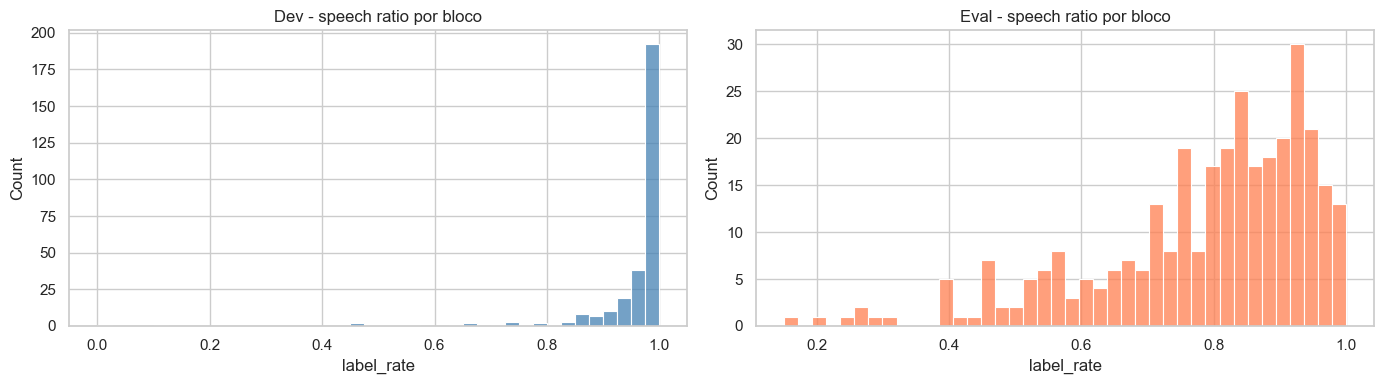

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(blocks_dev['label_rate'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Dev - speech ratio por bloco')
axes[0].set_xlabel('label_rate')

sns.histplot(blocks_eval['label_rate'], bins=40, ax=axes[1], color='coral')
axes[1].set_title('Eval - speech ratio por bloco')
axes[1].set_xlabel('label_rate')

plt.tight_layout()
plt.show()

In [10]:
rec_dev = blocks_dev.groupby('recording_id').agg(
    n_blocks=('sample_id', 'nunique'),
    mean_label_rate=('label_rate', 'mean'),
).sort_values('n_blocks', ascending=False)

rec_eval = blocks_eval.groupby('recording_id').agg(
    n_blocks=('sample_id', 'nunique'),
    mean_label_rate=('label_rate', 'mean'),
).sort_values('n_blocks', ascending=False)

print('Top recordings por número de blocos (dev):')
display(rec_dev.head(10))

print('Top recordings por número de blocos (eval):')
display(rec_eval.head(10))

Top recordings por número de blocos (dev):


,n_blocks,mean_label_rate
recording_id,,
S02_U06,296,0.950662


Top recordings por número de blocos (eval):


,n_blocks,mean_label_rate
recording_id,,
S01_U06,318,0.785964


## 6. Famílias de features (log-mel e spatial)

In [11]:
all_cols = dev_cols
log_mel_cols = [c for c in all_cols if c.startswith('log_mel_')]
spatial_cols = [c for c in all_cols if c.startswith('spatial_')]

print('n_log_mel:', len(log_mel_cols))
print('n_spatial:', len(spatial_cols))
print('target col:', 'label' in all_cols)

n_log_mel: 128
n_spatial: 4
target col: True


In [12]:
# Amostra para estatística rápida de features sem carregar tudo em RAM
sample_n = 120000
df_feat_sample = pd.read_csv(DEV_CSV, usecols=log_mel_cols[:8] + spatial_cols + ['label'])
if len(df_feat_sample) > sample_n:
    df_feat_sample = df_feat_sample.sample(sample_n, random_state=42)

display(df_feat_sample.describe().T[['mean', 'std', 'min', 'max']].round(4))

,mean,std,min,max
log_mel_0,0.0038,1.0013,-0.9914,4.6530
log_mel_1,0.0021,1.0004,-1.3249,3.8852
log_mel_2,0.0019,1.0017,-0.9774,6.3184
log_mel_3,0.0028,1.0026,-0.8679,11.1563
log_mel_4,0.0023,1.0031,-0.8392,6.1454
log_mel_5,0.0022,1.0041,-0.8249,5.6086
log_mel_6,0.0011,1.0033,-0.5299,7.2492
log_mel_7,-0.0015,0.9966,-0.4443,8.9610
spatial_0,-0.0011,0.6968,-19.4147,22.0887
spatial_1,0.0001,0.7091,-27.8182,38.5570
